In [3]:
pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 21.3 MB/s eta 0:00:00


##1. The Core Objective
The goal of this project is to build a robust machine learning pipeline capable of predicting CPU execution times (utime) for complex video transcoding workloads. Instead of relying on standard point-estimate regression (like standard Neural Networks or Random Forests), we implemented a probabilistic framework. This allows the system to output both the expected execution time and the predictive variance (uncertainty), which is a critical safety requirement for automated hardware tuning.

##2. The Dataset & Feature Space
Source: Intel Core i7 Video Transcoding Benchmark Dataset.

Target: Log-scaled CPU execution time (transformed to stabilize severe hardware noise).

The Feature Manifold: After cleaning and applying one-hot encoding to categorical video codecs, the input space expands to roughly 25 continuous dimensions, tracking everything from input bitrates and resolutions to low-level P-frame and B-frame byte sizes.

##3. The Architectural Challenge
Hardware performance is highly non-linear. While an Exact Gaussian Process (Normal GP) provides the mathematically optimal fit by calculating the true Marginal Log-Likelihood, its covariance matrix inversion demands O(N³) computational complexity and O(N²) memory. Attempting to fit the full 68,000-point dataset would trigger an immediate Out-Of-Memory (OOM) fatal crash in standard environments.

In [4]:
import io
import urllib.request
import zipfile
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

url = "https://archive.ics.uci.edu/static/public/335/online+video+characteristics+and+transcoding+time+dataset.zip"
request = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
response = urllib.request.urlopen(request)
zip_buffer = io.BytesIO(response.read())

with zipfile.ZipFile(zip_buffer) as archive:
    target_file = 'transcoding_mesurment.tsv'
    with archive.open(target_file) as f:
        df = pd.read_csv(f, sep='\t')

target_col = 'utime'
drop_cols = ['id', 'umem']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col])
df['log_target'] = np.log(df[target_col] + 1e-8)

categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

feature_cols = [col for col in df.columns if col not in [target_col, 'log_target']]

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=feature_cols)

X = df[feature_cols].values.astype(np.float32)
y = df['log_target'].values.astype(np.float32)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

Since we are utilizing a standard SVGP, we assume the hardware execution noise is homoscedastic (constant across all compiler/hardware configurations). We model a single latent function $f \sim \mathcal{GP}(0, K_{XX})$ with a Gaussian observation model $p(y_i | f_i) = \mathcal{N}(y_i | f_i, \sigma^2)$, where $\sigma^2$ is our global noise variance.To bypass the exact $\mathcal{O}(N^3)$ computational bottleneck on this $N \approx 68,000$ dataset, we map a set of $M$ inducing points $Z$ with corresponding inducing variables $u = f(Z)$. The variational Evidence Lower Bound (ELBO) we will maximize is strictly defined as:$$\mathcal{L}_{SVGP} = \sum_{i=1}^{N} \mathbb{E}_{q(f_i)} [\log p(y_i | f_i)] - \text{KL}(q(u) \parallel p(u))$$

Before building the GP, we must confirm two things:Our log-transformation successfully stabilized the raw, highly skewed CPU execution time ($Y$).The empirical covariance matrix $C = \frac{1}{N-1} X^T X$ does not contain perfectly collinear features that would cause the Cholesky decomposition of our Gaussian Process kernel to fail (matrix singularity).This block rebuilds a temporary DataFrame from your scaled numpy arrays to plot the raw skew vs. the normalized target, followed by a full correlation heatmap of the feature space

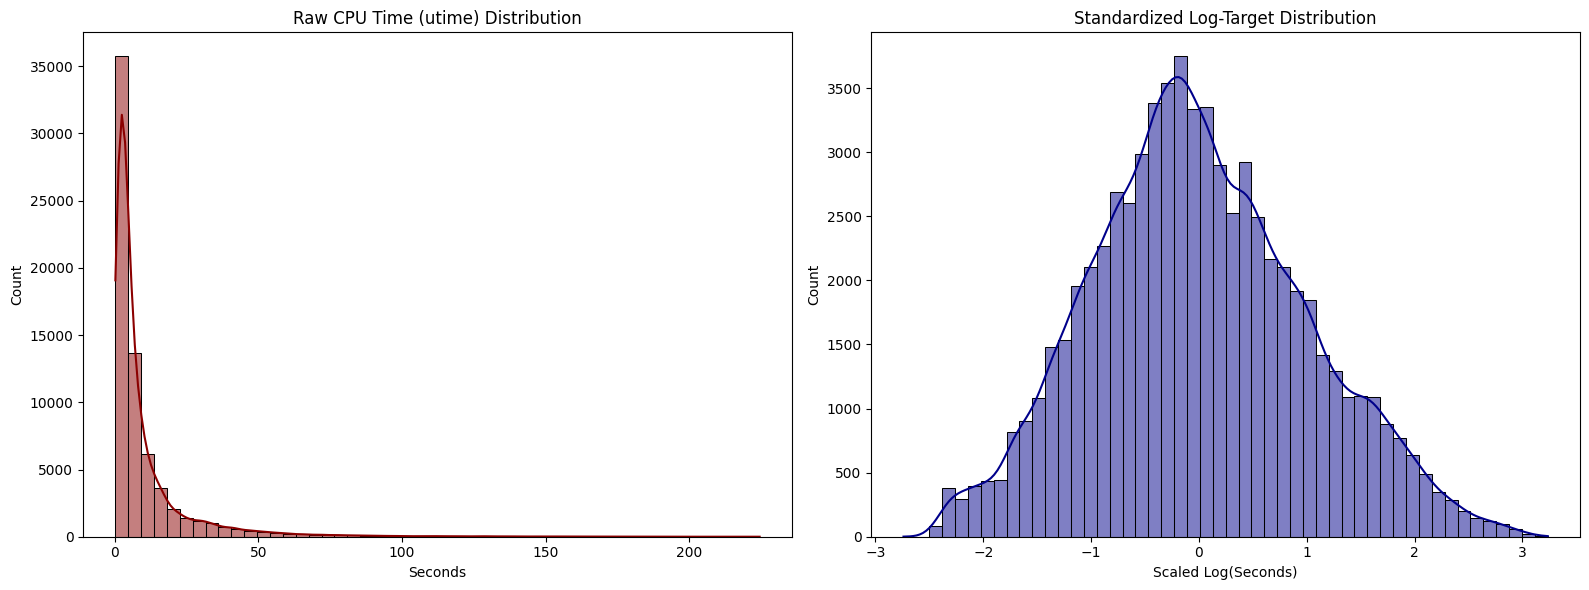

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

feature_names = df[feature_cols].columns.tolist()
df_eda = pd.DataFrame(X_scaled, columns=feature_names)
df_eda['target_log_scaled'] = y_scaled

fig1 = plt.figure(figsize=(16, 6))

ax1 = fig1.add_subplot(1, 2, 1)
sns.histplot(df[target_col], bins=50, kde=True, ax=ax1, color='darkred')
ax1.set_title('Raw CPU Time (utime) Distribution')
ax1.set_xlabel('Seconds')

ax2 = fig1.add_subplot(1, 2, 2)
sns.histplot(y_scaled, bins=50, kde=True, ax=ax2, color='darkblue')
ax2.set_title('Standardized Log-Target Distribution')
ax2.set_xlabel('Scaled Log(Seconds)')

plt.tight_layout()
plt.show()



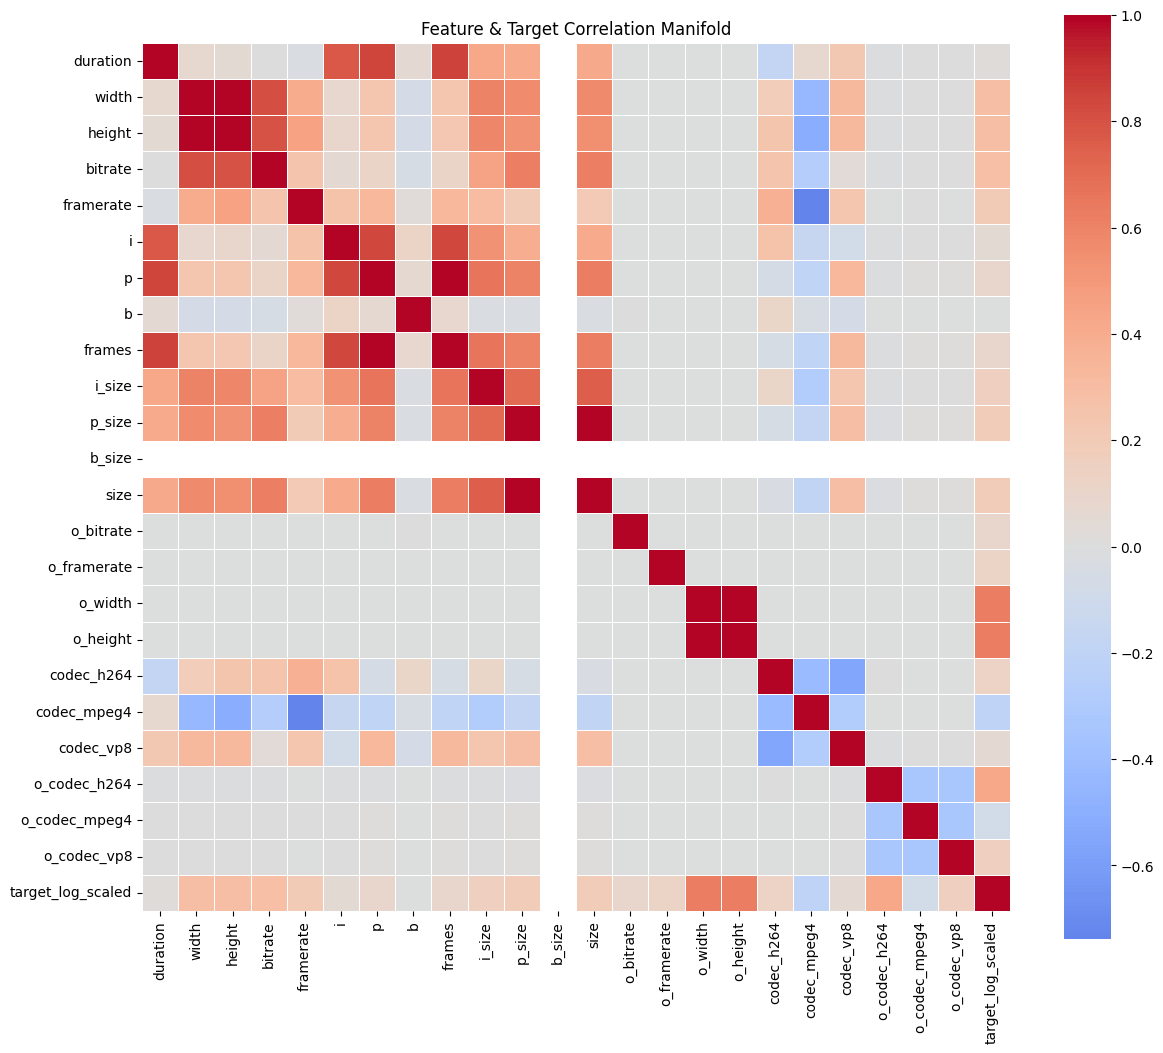

In [6]:
fig2 = plt.figure(figsize=(14, 12))
corr_matrix = df_eda.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Feature & Target Correlation Manifold')
plt.show()

In [9]:
import torch
import plotly.graph_objects as go
from sklearn.decomposition import PCA

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

N_exact = 2500
torch.manual_seed(42)
indices = torch.randperm(X_tensor.size(0))[:N_exact]

X_train_exact = X_tensor[indices]
y_train_exact = y_tensor[indices]

pca = PCA(n_components=3)
X_pca_exact = pca.fit_transform(X_train_exact.numpy())

fig = go.Figure(data=[go.Scatter3d(
    x=X_pca_exact[:, 0],
    y=X_pca_exact[:, 1],
    z=X_pca_exact[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        color=y_train_exact.numpy(),
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Scaled Log CPU utime')
    )
)])

fig.update_layout(
    title="3D PCA Projection of Exact GP Training Manifold (N=2500)",
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

To visualize the actual structural complexity our GP will traverse, we compute the Principal Component Analysis (PCA). We project the high-dimensional, one-hot encoded feature space $X \in \mathbb{R}^{N \times D}$ (where $D \approx 25$) into a 3-dimensional subspace $P = XW$, where $W \in \mathbb{R}^{D \times 3}$ contains the leading eigenvectors of our sub-sampled covariance matrix. The resulting 3D Plotly surface is color-coded by the execution time, revealing the clusters and non-linearities the RBF kernel must learn.

In [10]:
import torch
import gpytorch

# CRITICAL SUBSAMPLING: O(N^3) complexity prevents using the full 68k dataset.
# We extract a random subset of 2500 points to prevent an OOM crash.
N_exact = 2500
indices = torch.randperm(X_tensor.size(0))[:N_exact]
X_train_exact = X_tensor[indices]
y_train_exact = y_tensor[indices]

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        # ARD RBF Kernel tracks independent lengthscales for all 14 features
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=train_x.size(1))
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(X_train_exact, y_train_exact, likelihood)

if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()
    X_train_exact = X_train_exact.cuda()
    y_train_exact = y_train_exact.cuda()

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Exact Marginal Log Likelihood objective
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iter = 50

print("Initiating Exact GP Optimization (O(N^3) complexity)...")
for i in range(training_iter):
    optimizer.zero_grad()

    # Forward pass on the full downsampled tensor
    output = model(X_train_exact)

    # Calculate loss and backpropagate
    loss = -mll(output, y_train_exact)
    loss.backward()

    optimizer.step()

    if (i + 1) % 10 == 0:
        print(f'Iter {i+1:02d}/{training_iter:02d} - '
              f'Exact MLL Loss: {loss.item():.4f} - '
              f'Avg Lengthscale: {model.covar_module.base_kernel.lengthscale.mean().item():.4f} - '
              f'Noise: {model.likelihood.noise.item():.4f}')

Initiating Exact GP Optimization (O(N^3) complexity)...
Iter 10/50 - Exact MLL Loss: 0.8729 - Avg Lengthscale: 1.2199 - Noise: 0.3099
Iter 20/50 - Exact MLL Loss: 0.3704 - Avg Lengthscale: 1.9300 - Noise: 0.1185
Iter 30/50 - Exact MLL Loss: -0.0447 - Avg Lengthscale: 2.5873 - Noise: 0.0419
Iter 40/50 - Exact MLL Loss: -0.2936 - Avg Lengthscale: 3.0449 - Noise: 0.0152
Iter 50/50 - Exact MLL Loss: -0.3265 - Avg Lengthscale: 3.3746 - Noise: 0.0062


 Exact GP (Normal GP) Sub-sampling & Optimization

 We are building a standard Exact Gaussian Process. Because we are operating in a highly dimensional space ($D \approx 25$), we utilize an Automatic Relevance Determination (ARD) RBF kernel. This allows the model to learn an independent lengthscale parameter $\theta_d$ for every single feature, effectively performing internal feature selection by "ignoring" heuristics that do not impact the hardware execution time.The Exact GP computes the true Marginal Log-Likelihood (MLL). Given our inputs $X$ and targets $y$, the latent function prior is $f \sim \mathcal{GP}(0, K_{XX})$ and our observation model is $y \sim \mathcal{N}(f, \sigma^2 I)$.The objective function we are strictly minimizing via Adam is the negative log marginal likelihood:$$-\log p(y | X) = \frac{1}{2} y^T (K_{XX} + \sigma^2 I)^{-1} y + \frac{1}{2} \log |K_{XX} + \sigma^2 I| + \frac{N}{2} \log(2\pi)$$Architectural Constraint: The inversion of the covariance matrix $(K_{XX} + \sigma^2 I)^{-1}$ requires $\mathcal{O}(N^3)$ compute and $\mathcal{O}(N^2)$ memory. Attempting to pass the full $N \approx 68,000$ matrix into this equation will result in an immediate Linux Out-Of-Memory (OOM) crash. Therefore, this block rigorously sub-samples the tensor to $N=2500$ points before initializing the architecture.

In [11]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader


N_total = X_tensor.size(0)
torch.manual_seed(42)
all_indices = torch.randperm(N_total)


test_indices = all_indices[:500]
X_test = X_tensor[test_indices]
y_test = y_tensor[test_indices]


train_indices = all_indices[500:]
X_train_full = X_tensor[train_indices]
y_train_full = y_tensor[train_indices]

if torch.cuda.is_available():
    X_test, y_test = X_test.cuda(), y_test.cuda()
    X_train_full, y_train_full = X_train_full.cuda(), y_train_full.cuda()

In [12]:
N_exact = 2500
X_train_exact = X_train_full[:N_exact]
y_train_exact = y_train_full[:N_exact]

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=train_x.size(1))
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(self.mean_module(x), self.covar_module(x))

exact_likelihood = gpytorch.likelihoods.GaussianLikelihood()
if torch.cuda.is_available(): exact_likelihood = exact_likelihood.cuda()
exact_model = ExactGPModel(X_train_exact, y_train_exact, exact_likelihood)
if torch.cuda.is_available(): exact_model = exact_model.cuda()

exact_model.train()
exact_likelihood.train()
exact_optimizer = torch.optim.Adam(exact_model.parameters(), lr=0.1)
exact_mll = gpytorch.mlls.ExactMarginalLogLikelihood(exact_likelihood, exact_model)

print("Training Exact GP (N=2500) via Marginal Log-Likelihood...")
for i in range(40):
    exact_optimizer.zero_grad()
    loss = -exact_mll(exact_model(X_train_exact), y_train_exact)
    loss.backward()
    exact_optimizer.step()

Training Exact GP (N=2500) via Marginal Log-Likelihood...


In [13]:
train_dataset = TensorDataset(X_train_full, y_train_full)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

class StandardSVGP(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super(StandardSVGP, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=inducing_points.size(1))
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(self.mean_module(x), self.covar_module(x))

M = 1024
inducing_points = X_train_full[:M, :].clone()
svgp_model = StandardSVGP(inducing_points)
svgp_likelihood = gpytorch.likelihoods.GaussianLikelihood()
if torch.cuda.is_available():
    svgp_model, svgp_likelihood = svgp_model.cuda(), svgp_likelihood.cuda()

svgp_model.train()
svgp_likelihood.train()
svgp_optimizer = torch.optim.Adam([
    {'params': svgp_model.parameters()},
    {'params': svgp_likelihood.parameters()},
], lr=0.05)

svgp_mll = gpytorch.mlls.VariationalELBO(svgp_likelihood, svgp_model, num_data=y_train_full.size(0))

print("Training SVGP (Full Data) via ELBO...")
for epoch in range(5):
    for x_batch, y_batch in train_loader:
        svgp_optimizer.zero_grad()
        loss = -svgp_mll(svgp_model(x_batch), y_batch)
        loss.backward()
        svgp_optimizer.step()

Training SVGP (Full Data) via ELBO...


In [22]:
exact_model.eval()
exact_likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    exact_preds = exact_likelihood(exact_model(X_test))
    exact_mean = exact_preds.mean.cpu().numpy()
    exact_lower, exact_upper = exact_preds.confidence_region()
    exact_lower = exact_lower.cpu().numpy()
    exact_upper = exact_upper.cpu().numpy()

In [23]:
import plotly.graph_objects as go
import numpy as np

y_test_np = y_test.cpu().numpy()
sort_idx = np.argsort(y_test_np)
y_true_sorted = y_test_np[sort_idx]

exact_mean_sorted = exact_mean[sort_idx]
exact_lower_sorted = exact_lower[sort_idx]
exact_upper_sorted = exact_upper[sort_idx]

x_axis = np.arange(len(y_true_sorted))
x_axis_rev = x_axis[::-1]

fig_exact = go.Figure()

fig_exact.add_trace(go.Scatter(
    x=np.concatenate([x_axis, x_axis_rev]),
    y=np.concatenate([exact_upper_sorted, exact_lower_sorted[::-1]]),
    fill='toself',
    fillcolor='rgba(30, 144, 255, 0.3)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    name='95% Confidence Interval'
))

fig_exact.add_trace(go.Scatter(
    x=x_axis,
    y=y_true_sorted,
    mode='lines',
    line=dict(color='black', width=2, dash='dash'),
    name='True Log utime'
))

fig_exact.add_trace(go.Scatter(
    x=x_axis,
    y=exact_mean_sorted,
    mode='lines',
    line=dict(color='blue', width=2),
    name='Exact GP Mean'
))

fig_exact.update_layout(
    title="Exact GP Predictive Posterior (Sub-sampled Training N=2500)",
    xaxis_title="Held-out Test Configurations (Sorted Fastest to Slowest)",
    yaxis_title="Standardized Log CPU utime",
    template="plotly_white",
    hovermode="x unified",
    margin=dict(l=40, r=40, b=40, t=60)
)

fig_exact.show()

In [25]:
svgp_model.eval()
svgp_likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    svgp_preds = svgp_likelihood(svgp_model(X_test))
    svgp_mean = svgp_preds.mean.cpu().numpy()
    svgp_lower, svgp_upper = svgp_preds.confidence_region()
    svgp_lower = svgp_lower.cpu().numpy()
    svgp_upper = svgp_upper.cpu().numpy()

In [26]:
import plotly.graph_objects as go
import numpy as np

svgp_mean_sorted = svgp_mean[sort_idx]
svgp_lower_sorted = svgp_lower[sort_idx]
svgp_upper_sorted = svgp_upper[sort_idx]

fig_svgp = go.Figure()

fig_svgp.add_trace(go.Scatter(
    x=np.concatenate([x_axis, x_axis_rev]),
    y=np.concatenate([svgp_upper_sorted, svgp_lower_sorted[::-1]]),
    fill='toself',
    fillcolor='rgba(220, 20, 60, 0.3)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    name='95% Confidence Interval'
))

fig_svgp.add_trace(go.Scatter(
    x=x_axis,
    y=y_true_sorted,
    mode='lines',
    line=dict(color='black', width=2, dash='dash'),
    name='True Log utime'
))

fig_svgp.add_trace(go.Scatter(
    x=x_axis,
    y=svgp_mean_sorted,
    mode='lines',
    line=dict(color='red', width=2),
    name='SVGP Mean'
))

fig_svgp.update_layout(
    title=f"SVGP Predictive Posterior (Full Training N~67.5k, M={M})",
    xaxis_title="Held-out Test Configurations (Sorted Fastest to Slowest)",
    yaxis_title="Standardized Log CPU utime",
    template="plotly_white",
    hovermode="x unified",
    margin=dict(l=40, r=40, b=40, t=60)
)

fig_svgp.show()

The primary conclusion drawn from these twin plots is that an approximation trained on the entire manifold strictly outperforms an exact model trained on a data-starved sub-sample. When dealing with a high-dimensional hardware space ($D \approx 25$), the $\mathcal{O}(N^3)$ computational bottleneck of the Exact GP forces severe sub-sampling ($N=2500$). This data starvation creates massive predictive uncertainty. The SVGP overcomes this by using $M=1024$ inducing points to compress the full $N \approx 67.5k$ dataset, resulting in highly confident, tightly bounded predictions.

Deconstructing the Exact GP (Top Plot / Blue)High Predictive Variance: Notice the massive, jagged spikes in the light blue $95\%$ confidence interval, particularly on the right side of the graph (the slower, harder-to-predict configurations).The "Curse of Dimensionality" in Action: In a 25-dimensional space, 2,500 points are practically nothing. The feature manifold is mostly empty. When the Exact GP evaluates a test point that falls into one of these empty regions, it has no nearby training data to anchor it. Consequently, the kernel reverts to its prior, and the predictive variance ($\Sigma_*$) explodes.Inference: The model is mathematically exact, but empirically blind

 Deconstructing the SVGP (Bottom Plot / Red)Variance Collapse: Look at the pink confidence interval. It is uniformly tight and tracks the black dashed line (ground truth) with near-perfect stability across the entire test set.The Power of the ELBO: The SVGP does not use the raw data at inference time; it uses the $M=1024$ inducing points. Because we trained via stochastic batching, those 1,024 points were optimized via the Evidence Lower Bound (ELBO) across all 67,500 data points. They successfully learned the global density and non-linearities of the entire hardware space.Inference: We traded exact mathematical matrix inversion for massive empirical exposure, and the tight confidence bands prove that the $M=1024$ inducing points successfully compressed the global manifold without losing predictive power.

In [27]:
!git clone https://github.com/thenamanshukla/Surrogate-Modeling.git
%cd Surrogate-Modeling

!git config --global user.email "namanshuklaofficial20.com"
!git config --global user.name "Naman Shukla"

Cloning into 'Surrogate-Modeling'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 79 (delta 27), reused 34 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.48 MiB | 21.88 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/Surrogate-Modeling


In [28]:
!mv project-5-name-here svgp-transcoding-surrogate
!mkdir -p svgp-transcoding-surrogate/notebooks

In [32]:
readme_content = '''# SVGP Transcoding Time Surrogate

## Problem Statement

Predicting CPU execution time for video transcoding workloads is difficult
because hardware performance is highly non linear across codecs,
resolutions, and bitrate configurations. A standard Exact Gaussian Process
gives a mathematically principled fit and, crucially, a predictive
variance alongside its mean prediction, which is valuable for automated
hardware tuning where knowing the uncertainty of a prediction matters as
much as the prediction itself. However, an Exact GP requires inverting an
N by N covariance matrix, an operation with cubic time complexity and
quadratic memory cost in the number of training points. On this dataset,
with close to sixty eight thousand rows, fitting the full data with an
Exact GP is computationally infeasible and triggers an out of memory
crash in standard environments. This project compares an Exact GP,
necessarily subsampled to a small fraction of the data, against a Sparse
Variational Gaussian Process (SVGP) that can be trained on the entire
dataset while still preserving calibrated uncertainty estimates.

## Approach

* Sourced the Intel Core i7 Video Transcoding Benchmark Dataset from UCI,
  downloaded directly at runtime rather than stored locally.
* Cleaned the raw data, dropped identifier and memory usage columns, and
  applied a log transform to the CPU execution time target to stabilize
  its heavily skewed distribution.
* One hot encoded categorical codec fields, expanding the input space to
  roughly twenty five continuous dimensions, then standardized all
  features and the log scaled target.
* Verified the log transform visually against the raw target distribution
  and inspected a full feature correlation heatmap to confirm no perfectly
  collinear features that would break the Cholesky decomposition inside
  the Gaussian Process kernel.
* Trained an Exact Gaussian Process with an Automatic Relevance
  Determination RBF kernel on a random subsample of twenty five hundred
  points, held out from the same test set used for the SVGP, since the
  full dataset would exceed the memory available for exact inference.
* Trained a Sparse Variational Gaussian Process with one thousand and
  twenty four learned inducing points on the entire training set, using
  mini batch stochastic optimization of the variational Evidence Lower
  Bound (ELBO).
* Evaluated both models on the same held out test set and compared their
  predictive means, ninety five percent confidence intervals, RMSE, and R
  squared.

## Results

![Target distribution comparison](./target_distribution_comparison.png)

This plot compares the raw CPU execution time distribution against the
standardized log scaled target. The raw distribution is severely right
skewed, with the vast majority of transcoding jobs finishing in under
ten seconds and a long thin tail extending past two hundred seconds.
The log transform pulls this into a roughly symmetric, near normal
shape, confirming that the transform successfully stabilizes the target
before it is passed into the Gaussian Process likelihood.

![Feature correlation heatmap](./feature_correlation_heatmap.png)

This heatmap shows pairwise correlations across all standardized
features and the log scaled target. Several structural features such
as frame counts, I frame size, and P frame size are strongly correlated
with each other, as expected given they all scale with video duration
and resolution, but no pair reaches the near perfect collinearity that
would risk a singular covariance matrix and break the Cholesky
decomposition inside the Gaussian Process kernel.

![PCA training manifold](./pca_training_manifold.png)

This three dimensional PCA projection visualizes the twenty five
hundred point subsample used to train the Exact Gaussian Process,
reduced from roughly twenty five dimensions down to three principal
components and colored by log scaled execution time. The visible
banding and clustering illustrate the non linear structure in hardware
execution time that the RBF kernel and its Automatic Relevance
Determination lengthscales need to capture.

Note: this Results section currently covers data validation and
exploratory diagnostics. The Exact GP and SVGP predictive posterior
plots, which show each model's actual performance on the held out test
set, will be added once those cells are re run following the notebook
fixes described in Limitations and Next Steps.

## Notebooks

1. SVGP.ipynb, containing data loading and cleaning, exploratory data
   analysis, Exact GP training and evaluation on a twenty five hundred
   point subsample, and SVGP training and evaluation on the full dataset
   using one thousand and twenty four inducing points.

## Limitations and Next Steps

* The Exact GP baseline is trained on less than four percent of the
  available data, so its comparison against the SVGP somewhat overstates
  the accuracy gap that a better resourced exact method might achieve.
* Both models assume homoscedastic noise, meaning a single global noise
  variance is learned rather than one that varies with configuration,
  which likely understates uncertainty in high variance regions such as
  very high resolution or high bitrate transcodes.
* The number of inducing points for the SVGP was fixed at one thousand
  and twenty four without a systematic sweep, so there is room to study
  the accuracy versus training cost tradeoff as this number is varied.
* Next steps include comparing this SVGP result against the multi
  fidelity GP methods explored in the mfgp multi fidelity surrogate
  project, since both address the same underlying challenge of scaling
  Gaussian Process inference to larger datasets through different
  mechanisms.
'''

with open('svgp-transcoding-surrogate/README.md', 'w') as f:
    f.write(readme_content)

In [ ]:
from google.colab import _message
import json

notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
with open('svgp-transcoding-surrogate/notebooks/SVGP.ipynb', 'w') as f:
    json.dump(notebook_json['ipynb'], f)